# Imports

In [1]:
import custom_utils as u
from custom_utils import CustomXValPhi3forCausalLM
from datasets import DatasetDict

from transformers import AutoTokenizer, set_seed
from trl import SFTConfig

from peft import LoraConfig, TaskType

set_seed(42)

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

C:\Users\Marlow\anaconda3\envs\MA_New_Install\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
baseline_model_name = 'microsoft/Phi-3-mini-128k-instruct'
custom_model_name = 'LoRA_LR_0_0001_r32_alpha_64_chat_format_wo_embeds'

In [3]:
custom_model = CustomXValPhi3forCausalLM.from_pretrained(baseline_model_name,
                                                         torch_dtype=torch.bfloat16,
                                                         # trust_remote_code=True,
                                                         # device_map=device,
                                                         device_map="auto",
                                                         attn_implementation="flash_attention_2")

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.95s/it]


In [4]:
custom_tokenizer = AutoTokenizer.from_pretrained('custom_tokenizer/modified_by_hand')

# Load and prepare Dataset

In [5]:
small_math_ds = DatasetDict.load_from_disk('datasets/small_math')
small_math_ds 

DatasetDict({
    train: Dataset({
        features: ['text', 'output'],
        num_rows: 200000
    })
    test: Dataset({
        features: ['text', 'output'],
        num_rows: 50000
    })
})

In [6]:
small_math_ds['train']

Dataset({
    features: ['text', 'output'],
    num_rows: 200000
})

In [7]:
# preparing the examples with a system message
def tokenize_output(example):
    example['text'] = f"<|system|> You are a calculation assistant. You only reply with the result.<|end|><|user|> Calculate this task: {example['text']}<|end|><|endoftext|>"
    return example
small_math_ds = small_math_ds.map(
    tokenize_output,
    load_from_cache_file=True, #False
)

In [8]:
small_math_ds['train']

Dataset({
    features: ['text', 'output'],
    num_rows: 200000
})

In [9]:
print("\nStarting tokenization...")
tokenize_lambda = lambda x: preprocess.tokenize_fnc(x, custom_tokenizer)
tokenized_ds = small_math_ds['train'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = small_math_ds['test'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
def tokenize_output(example):
    example['labels'] = custom_tokenizer.encode(example['output'])
    return example
tokenized_ds = tokenized_ds.map(
    tokenize_output,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = tokenized_ds_eval.map(
    tokenize_output,
    load_from_cache_file=True, #False
)


Starting tokenization...


In [10]:
tokenized_ds = tokenized_ds.remove_columns(['text', 'output', 'len'])
tokenized_ds

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 200000
})

In [11]:
tokenized_ds_eval = tokenized_ds_eval.remove_columns(['text', 'output', 'len'])
tokenized_ds_eval

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 50000
})

# Training

In [12]:
# Training arguments values currently commented out were tried during different attempts
args = SFTConfig(
    output_dir=f"G:\\Masterarbeit\\documented_models\\custom_xVal_Phi3_small_math_ds\\{custom_model_name}",
    seed=42,
    max_seq_length=512,
    remove_unused_columns=False,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    log_level="info",
    optim="adamw_torch",
    per_device_train_batch_size=64, #128,
    gradient_accumulation_steps=1, # 4 1
    per_device_eval_batch_size=256, #512,
    num_train_epochs=3,
    # dataset_text_field="text",

    save_strategy="epoch", #steps
    save_steps=1000, #625, #125
    logging_strategy="steps",
    logging_steps=20, #125
    logging_first_step=True,

    eval_strategy="steps", #"steps", #no epoch
    do_eval=True,
    eval_on_start=True, #True
    # prediction_loss_only= True,
    # bf16_full_eval=True,
    eval_steps=250, #625, #125
    
    learning_rate=1e-4, #5.0e-06, #1e-4
    warmup_ratio=0.2, #0.1
    lr_scheduler_type= "cosine", #"cosine", #"linear", "cosine_with_restarts"
    # lr_scheduler_kwargs={"num_cycles":2},
    max_grad_norm=1.0, #1.0 0.5 0.3
)

# Variante 2
peft_config = LoraConfig(
    r=32, #16,
    lora_alpha=64, #32,
    lora_dropout=0.05,
    task_type=TaskType.CAUSAL_LM,
    target_modules=['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"], #"all-linear",
    bias="none",
    modules_to_save=None,
)

Using auto half precision backend
***** Running training *****
  Num examples = 200,000
  Num Epochs = 3
  Instantaneous batch size per device = 64
  Total train batch size (w. parallel, distributed & accumulation) = 64
  Gradient Accumulation steps = 1
  Total optimization steps = 9,375
  Number of trainable parameters = 30,408,704

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256


Step,Training Loss,Validation Loss
0,No log,21.405083
250,1.212900,1.184108
500,1.181500,1.178692
750,1.151200,1.178227
1000,1.190100,1.177264
1250,1.192600,1.176559
1500,1.193600,1.176246
1750,1.167000,1.179892
2000,1.175400,1.178659
2250,1.182200,1.176674



***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256
Saving model checkpoint to G:\Masterarbeit\documented_models\custom_xVal_Phi3_small_math_ds\LoRA_LR_0_0001_r32_a

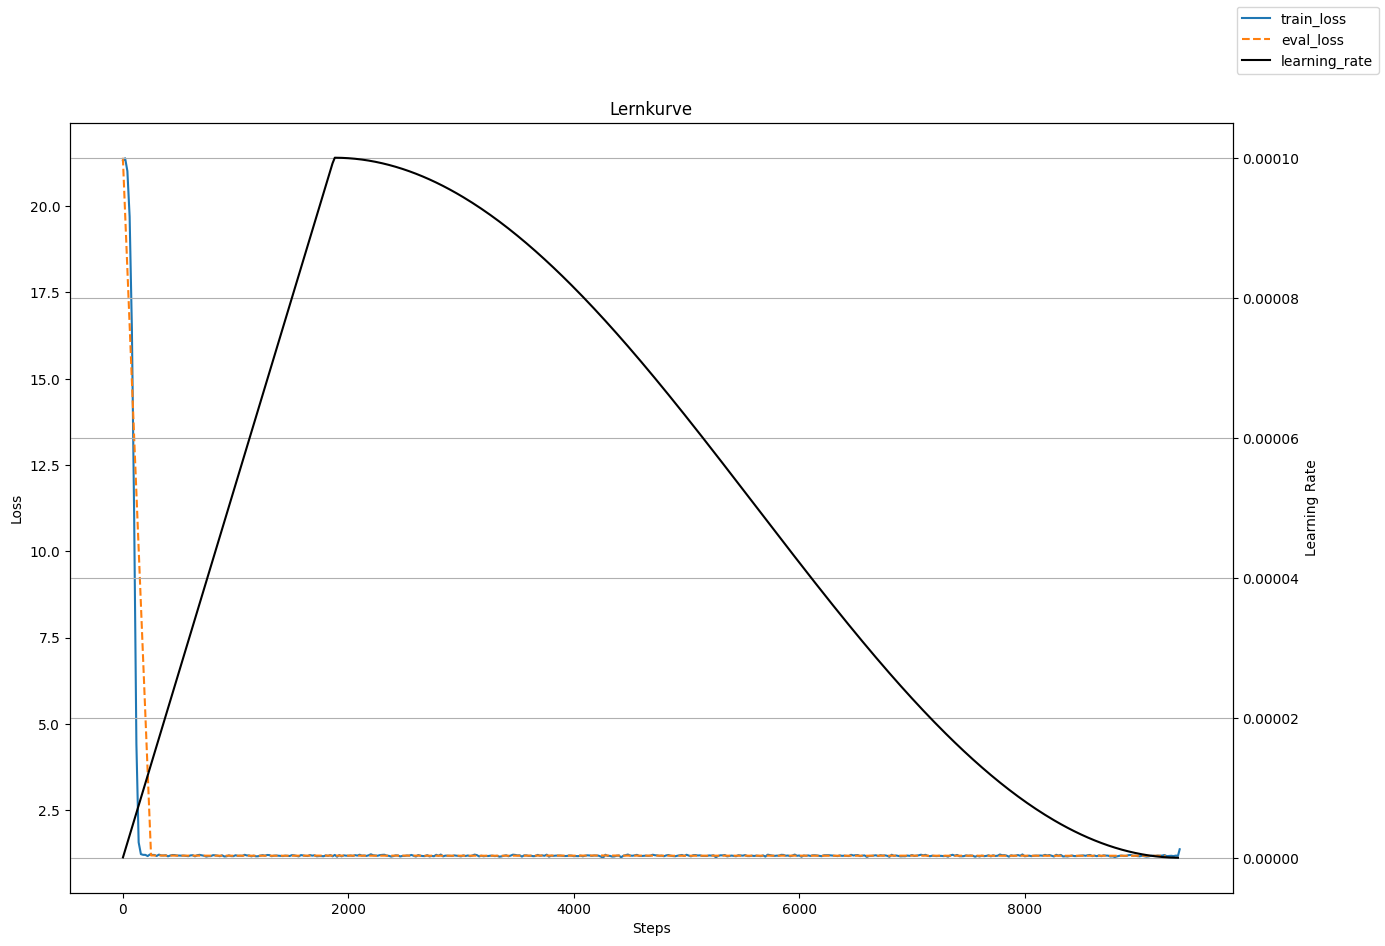

In [13]:
u.train_loop(sftconfig=args, 
             peftconfig=peft_config,
             model=custom_model,
             tokenizer=custom_tokenizer,
             train_ds=tokenized_ds,
             eval_ds=tokenized_ds_eval)

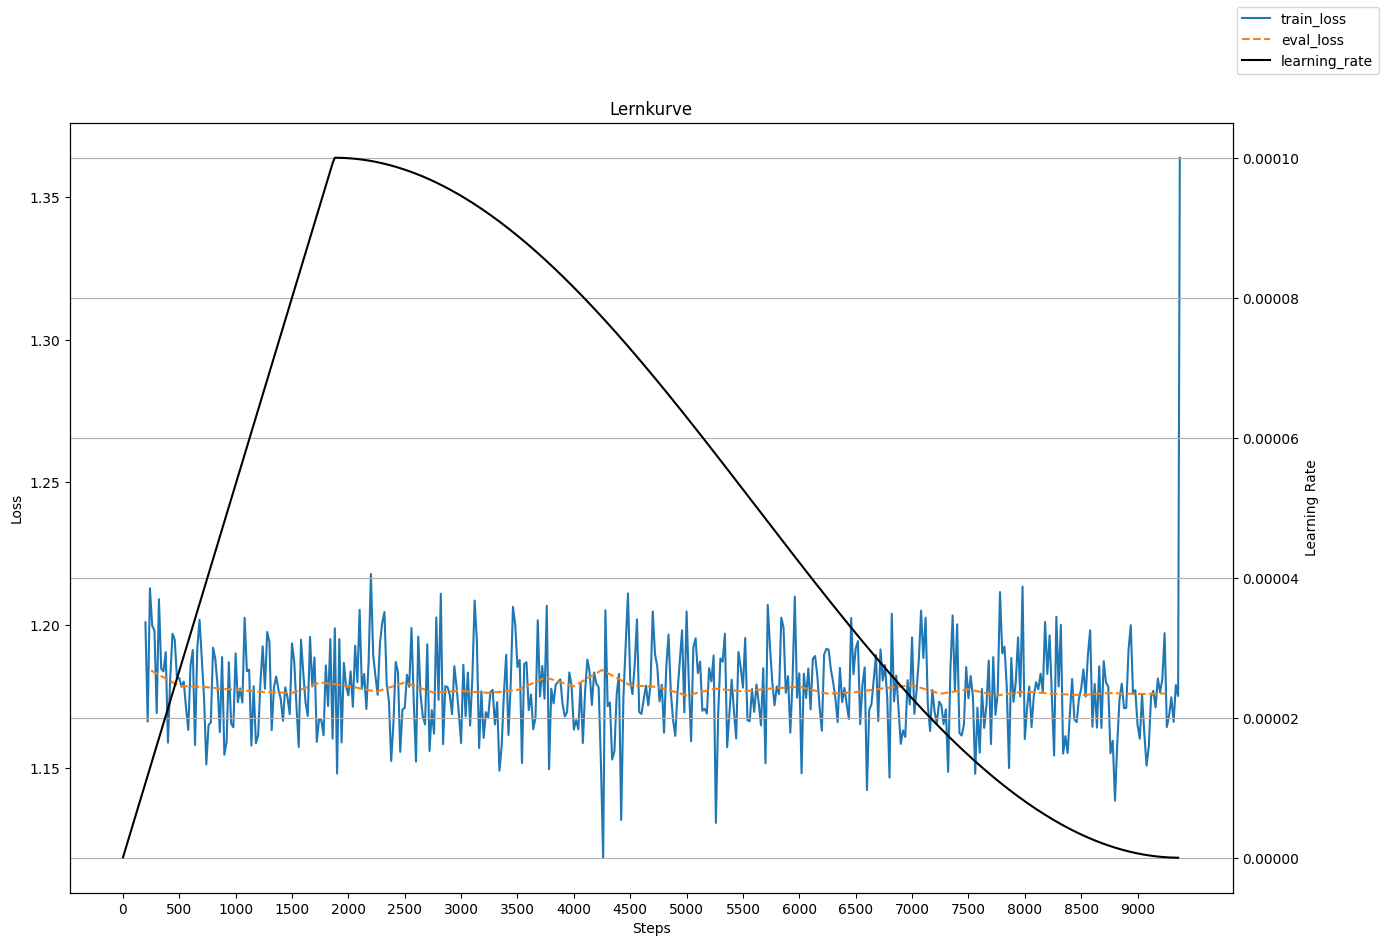

In [15]:
u.plot_lerningcurve(args.output_dir, skip_steps=10, tick_step_size=500)

# GSM8K Dataset

In [1]:
import custom_utils as u
from custom_utils import CustomXValPhi3forCausalLM
from datasets import load_dataset
from transformers import AutoTokenizer, set_seed
from trl import SFTConfig
from peft import LoraConfig, TaskType

set_seed(42)

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

C:\Users\Marlow\anaconda3\envs\MA_New_Install\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
baseline_model_name = 'microsoft/Phi-3-mini-128k-instruct'
custom_model_name = 'LoRA_LR_0_0001_r32_alpha_64_pred_number_wo_embeds'

In [3]:
custom_model = CustomXValPhi3forCausalLM.from_pretrained(baseline_model_name,
                                                         torch_dtype=torch.bfloat16,
                                                         # trust_remote_code=True,
                                                         # device_map=device,
                                                         device_map="auto",
                                                         attn_implementation="flash_attention_2")

Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.04s/it]


In [4]:
custom_tokenizer = AutoTokenizer.from_pretrained('custom_tokenizer/modified_by_hand')

In [5]:
# for name, module in custom_model.named_modules():
#     print(name, "->", type(module))

In [6]:
# for name, param in custom_model.state_dict().items():
#     print(name)

In [7]:
gsm8k_ds = load_dataset("openai/gsm8k", 'main')

In [8]:
gsm8k_ds

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})

In [9]:
gsm8k_ds['train']

Dataset({
    features: ['question', 'answer'],
    num_rows: 7473
})

In [10]:
gsm8k_ds = gsm8k_ds.rename_columns({'question': 'text', 'answer': 'output'})
gsm8k_ds['train']

Dataset({
    features: ['text', 'output'],
    num_rows: 7473
})

In [11]:
def clean_output(example):
    example['output'] = example['output'].split('####')[-1].strip()
    return example
gsm8k_ds['train'] = gsm8k_ds['train'].map(
    clean_output,
    load_from_cache_file=True, #False
)
gsm8k_ds['test'] = gsm8k_ds['test'].map(
    clean_output,
    load_from_cache_file=True, #False
)


In [12]:
gsm8k_ds['train']

Dataset({
    features: ['text', 'output'],
    num_rows: 7473
})

In [13]:
gsm8k_ds['test']

Dataset({
    features: ['text', 'output'],
    num_rows: 1319
})

In [14]:
print("\nStarting tokenization...")
tokenize_lambda = lambda x: preprocess.tokenize_fnc(x, custom_tokenizer)
tokenized_ds = gsm8k_ds['train'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = gsm8k_ds['test'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
def tokenize_output(example):
    example['labels'] = custom_tokenizer.encode(example['output'])
    return example
tokenized_ds = tokenized_ds.map(
    tokenize_output,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = tokenized_ds_eval.map(
    tokenize_output,
    load_from_cache_file=True, #False
)


Starting tokenization...


In [15]:
tokenized_ds = tokenized_ds.remove_columns(['text', 'output', 'len'])
tokenized_ds

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 7473
})

In [16]:
tokenized_ds_eval = tokenized_ds_eval.remove_columns(['text', 'output', 'len'])
tokenized_ds_eval

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 1319
})

In [17]:
args = SFTConfig(
    output_dir=f"G:\\Masterarbeit\\documented_models\\custom_xVal_Phi3_gsm8k_ds\\{custom_model_name}",
    seed=42,
    max_seq_length=512,
    remove_unused_columns=False,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    log_level="info",
    optim="adamw_torch",
    per_device_train_batch_size=4, #128,
    gradient_accumulation_steps=1, # 4 1
    per_device_eval_batch_size=16, #512,
    num_train_epochs=3,
    # dataset_text_field="text",

    save_strategy="epoch",
    save_steps=1000, #625, #125
    logging_strategy="steps",
    logging_steps=20, #125
    logging_first_step=True,

    eval_strategy="steps", #"steps", #no epoch
    do_eval=True,
    eval_on_start=True, #True
    # prediction_loss_only= True,
    # bf16_full_eval=True,
    eval_steps=250, #625, #125

    learning_rate=1e-4, #5.0e-06, #1e-4
    warmup_ratio=0.2, #0.1
    lr_scheduler_type= "cosine", #"cosine", #"linear", "cosine_with_restarts"
    # lr_scheduler_kwargs={"num_cycles":4},
    max_grad_norm=1.0, #1.0 0.5 0.3
)

# Variante 2
peft_config = LoraConfig(
    r=32, #16,
    lora_alpha=64, #32,
    lora_dropout=0.05,
    task_type=TaskType.CAUSAL_LM,
    target_modules=['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj'], # 'embed_tokens',  #, "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj'] ,# "all-linear", 
    #['k_proj', 'q_proj', 'v_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"]
    #['embed_tokens', 'qkv_proj', 'o_proj']
    bias="none",
    modules_to_save=None,
)

Using auto half precision backend
***** Running training *****
  Num examples = 7,473
  Num Epochs = 3
  Instantaneous batch size per device = 4
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 1
  Total optimization steps = 5,607
  Number of trainable parameters = 30,408,704

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16


Step,Training Loss,Validation Loss
0,No log,15.049562
250,0.098900,0.063923
500,0.084500,0.056792
750,0.077400,0.059974
1000,0.075200,0.059306
1250,0.075100,0.055351
1500,0.066400,0.054722
1750,0.089200,0.055613
2000,0.080000,0.054225
2250,0.064900,0.054345



***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16

***** Running Evaluation *****
  Num examples = 1319
  Batch size = 16
Saving model checkpoint to G:\Masterarbeit\documented_models\custom_xVal_Phi3_gsm8k_ds\LoRA_LR_0_0001_r32_alpha_64_pred_number_wo_embeds\checkpoint-1869
loading configuration file config.json from cache at C:\Users\Marlow\.cache\huggingface\hub\models--microsoft--Phi-3-mini-128k-instruct\snapshots\072cb7562cb8c4adf682a8e186aaafa49469eb5d\config.json
Model config Phi3Config {
  "_name_or_path": "Phi-3-mini-128k-instruct",
  "architectures": [
    "Phi3ForCausalLM"
  ],
  "attention_bias": fal

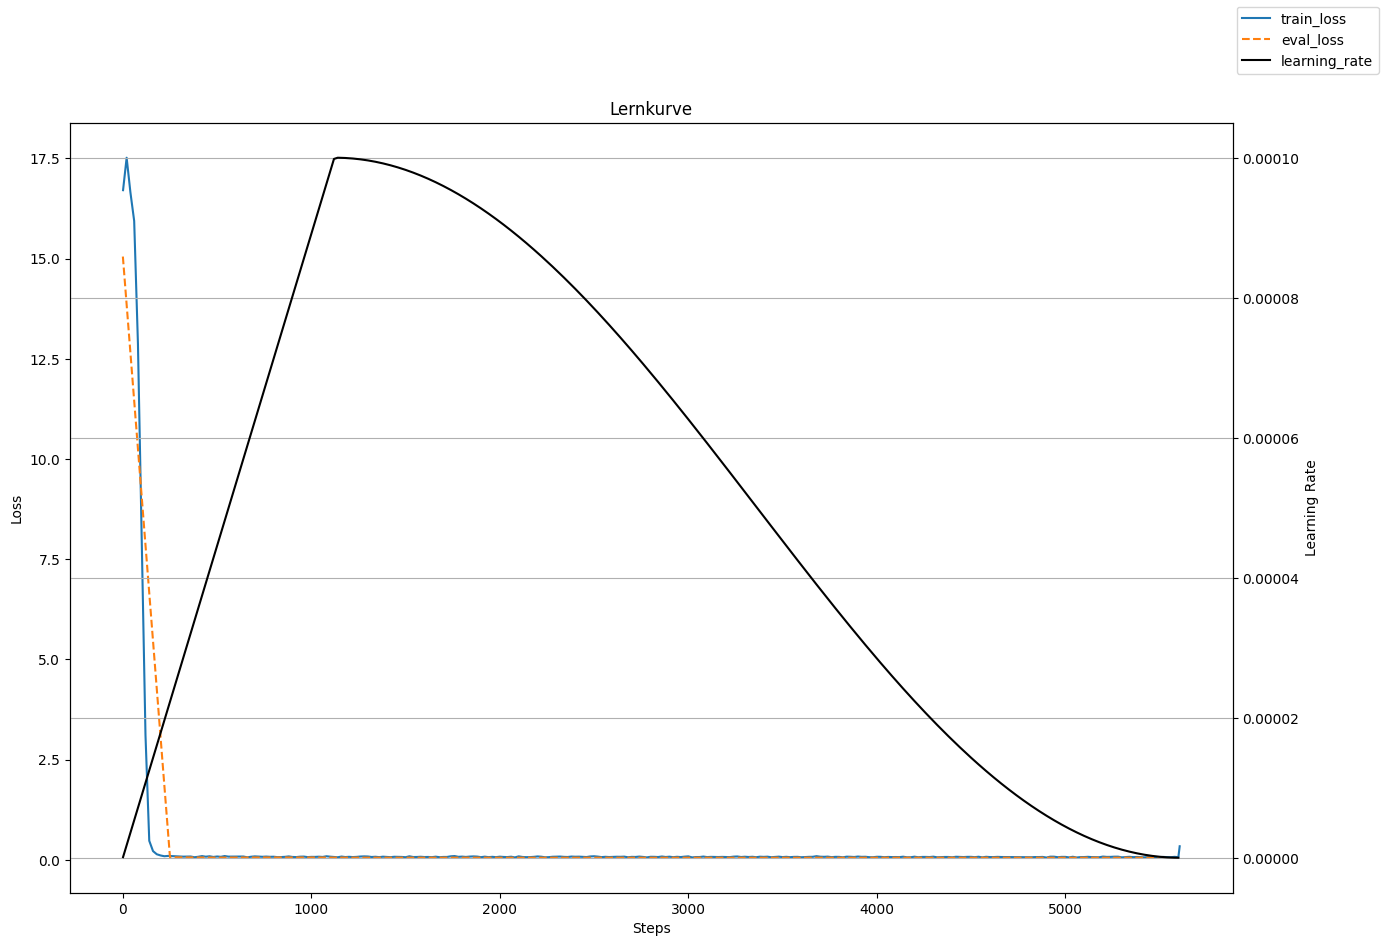

In [18]:
u.train_loop(sftconfig=args,
             peftconfig=peft_config,
             model=custom_model,
             tokenizer=custom_tokenizer,
             train_ds=tokenized_ds,
             eval_ds=tokenized_ds_eval,
             resume_from_checkpoint=False,
             )

In [17]:
param_grid = {
    "target_modules": [
        ['qkv_proj', 'o_proj'],
        ['qkv_proj', 'o_proj', 'embed_tokens'],
        ['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"],
        ['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj", 'embed_tokens']
    ],
    "r": [8, 16, 32],
    "alpha": [16, 32, 64],
    "learning_rate": [5e-5, 1e-4, 2e-4],
    "scheduler_type": ['cosine'],
    "dropout": [0.05],
    "warmup_ratio": [0.0, 0.1, 0.2],
}

In [18]:
4*2*2*1*1*1

16

# Custom Math Dataset

In [1]:
import custom_utils as u
from custom_utils import CustomXValPhi3forCausalLM
from datasets import DatasetDict

from transformers import AutoTokenizer, set_seed
from trl import SFTConfig

from peft import LoraConfig, TaskType


# ### xVal imports
from xval import preprocess

set_seed(42)

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

C:\Users\Marlow\anaconda3\envs\MA_New_Install\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
# custom_math_ds = u.create_math_tasks(250000, upper_bound=1000, lower_bound=-1000)
# custom_math_ds = custom_math_ds.train_test_split(train_size=0.8, shuffle=True, seed=42)
# custom_math_ds.save_to_disk("datasets/custom_math_ds")
# custom_math_ds

In [3]:
baseline_model_name = 'microsoft/Phi-3-mini-128k-instruct'
custom_model_name = 'LoRA_LR_0_0001_r32_alpha_64_wo_embeds_b4'

In [4]:
custom_model = CustomXValPhi3forCausalLM.from_pretrained(baseline_model_name,
                                                         torch_dtype=torch.bfloat16,
                                                         # trust_remote_code=True,
                                                         # device_map=device,
                                                         device_map="auto",
                                                         attn_implementation="flash_attention_2")

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.92s/it]


In [5]:
custom_tokenizer = AutoTokenizer.from_pretrained('custom_tokenizer/modified_by_hand')

In [6]:
custom_math_ds = DatasetDict.load_from_disk("datasets/custom_math_ds")

In [7]:
custom_math_ds['train']

Dataset({
    features: ['text', 'output'],
    num_rows: 200000
})

In [8]:
print("\nStarting tokenization...")
tokenize_lambda = lambda x: preprocess.tokenize_fnc(x, custom_tokenizer)
tokenized_ds = custom_math_ds['train'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = custom_math_ds['test'].map(
    tokenize_lambda,
    load_from_cache_file=True, #False
)
def tokenize_output(example):
    example['labels'] = custom_tokenizer.encode(example['output'])
    return example
tokenized_ds = tokenized_ds.map(
    tokenize_output,
    load_from_cache_file=True, #False
)
tokenized_ds_eval = tokenized_ds_eval.map(
    tokenize_output,
    load_from_cache_file=True, #False
)


Starting tokenization...


In [9]:
tokenized_ds = tokenized_ds.remove_columns(['text', 'output', 'len'])
tokenized_ds

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 200000
})

In [10]:
tokenized_ds_eval = tokenized_ds_eval.remove_columns(['text', 'output', 'len'])
tokenized_ds_eval

Dataset({
    features: ['input_ids', 'numbers', 'labels'],
    num_rows: 50000
})

# Training Custom Math Dataset

In [11]:
args = SFTConfig(
    output_dir=f"G:\\Masterarbeit\\documented_models\\custom_xVal_Phi3_custom_math_ds\\{custom_model_name}",
    seed=42,
    max_seq_length=512,
    remove_unused_columns=False,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    log_level="info",
    optim="adamw_torch",
    per_device_train_batch_size=4, #128,
    gradient_accumulation_steps=1, # 4 1
    per_device_eval_batch_size=256, #512,
    num_train_epochs=3,
    # dataset_text_field="text",

    save_strategy="steps",
    save_steps=250, #625, #125
    logging_strategy="steps",
    logging_steps=20, #125
    logging_first_step=True,

    eval_strategy="steps", #"steps", #no epoch
    do_eval=True,
    eval_on_start=True, #True
    # prediction_loss_only= True,
    # bf16_full_eval=True,
    eval_steps=250, #625, #125

    learning_rate=1e-4, #5.0e-06, #1e-4
    warmup_ratio=0.2, #0.1
    lr_scheduler_type= "cosine", #"cosine", #"linear", "cosine_with_restarts"
    # lr_scheduler_kwargs={"num_cycles":2},
    max_grad_norm=1.0, #1.0 0.5 0.3
)

# Variante 2
peft_config = LoraConfig(
    r=32, #16,
    lora_alpha=64, #32,
    lora_dropout=0.05,
    task_type=TaskType.CAUSAL_LM,
    target_modules=['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj'], # 'embed_tokens',  #, "gate_proj", "down_proj", "up_proj"],
    #['qkv_proj', 'o_proj'] ,# "all-linear", 
    #['k_proj', 'q_proj', 'v_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"]
    #['embed_tokens', 'qkv_proj', 'o_proj']
    bias="none",
    modules_to_save=None,
)

In [12]:
u.train_loop(sftconfig=args,
             peftconfig=peft_config,
             model=custom_model,
             tokenizer=custom_tokenizer,
             train_ds=tokenized_ds,
             eval_ds=tokenized_ds_eval,
             resume_from_checkpoint=False,
             )

Using auto half precision backend
***** Running training *****
  Num examples = 200,000
  Num Epochs = 3
  Instantaneous batch size per device = 4
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 1
  Total optimization steps = 150,000
  Number of trainable parameters = 30,408,704

***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256


Step,Training Loss,Validation Loss
0,No log,9.032365
250,0.000000,nan



***** Running Evaluation *****
  Num examples = 50000
  Batch size = 256
Saving model checkpoint to G:\Masterarbeit\documented_models\custom_xVal_Phi3_custom_math_ds\LoRA_LR_0_0001_r32_alpha_64_wo_embeds_b4\checkpoint-250
loading configuration file config.json from cache at C:\Users\Marlow\.cache\huggingface\hub\models--microsoft--Phi-3-mini-128k-instruct\snapshots\072cb7562cb8c4adf682a8e186aaafa49469eb5d\config.json
Model config Phi3Config {
  "_name_or_path": "Phi-3-mini-128k-instruct",
  "architectures": [
    "Phi3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "auto_map": {
    "AutoConfig": "microsoft/Phi-3-mini-128k-instruct--configuration_phi3.Phi3Config",
    "AutoModelForCausalLM": "microsoft/Phi-3-mini-128k-instruct--modeling_phi3.Phi3ForCausalLM"
  },
  "bos_token_id": 1,
  "embd_pdrop": 0.0,
  "eos_token_id": 32000,
  "hidden_act": "silu",
  "hidden_size": 3072,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings

KeyboardInterrupt: 